<a href="https://colab.research.google.com/github/Cyberpunk-San/ML-practice/blob/Residual-plots-and-Grid-Search/Residual_plots_and_Grid_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Residual plots and Grid Search -Scratch

In [4]:
import matplotlib.pyplot as plt

def plot_residuals(y_true, y_pred):
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 5))
    plt.scatter(y_pred, residuals, alpha=0.5, color='teal')
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title("Residual Plot: Checking for Heteroscedasticity")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals (Errors)")
    plt.show()

# If the points are randomly scattered around the red line, your model is healthy.
# If they form a 'U' shape, you need Polynomial Regression.

In [5]:
def grid_search_summary(model_class, X, y, param_grid, k=3):
    results = []
    for lr in param_grid['learning_rate']:
        for depth in param_grid['max_depth']:
            # Use the K-Fold function we just built
            scores = k_fold_cross_validation(model_class, X, y, k=k,
                                             learning_rate=lr, max_depth=depth)
            mean_score = np.mean(scores)
            results.append({'lr': lr, 'depth': depth, 'score': mean_score})
            print(f"Tested: LR={lr}, Depth={depth} | Mean CV Acc: {mean_score:.4f}")

    best = max(results, key=lambda x: x['score'])
    return best

# This turns "guessing" into "engineering."

In [6]:
from sklearn.metrics import precision_recall_curve

def plot_precision_recall_vs_threshold(y_true, probas_pred):
    precisions, recalls, thresholds = precision_recall_curve(y_true, probas_pred)

    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.title("Precision-Recall vs Threshold")
    plt.xlabel("Decision Threshold")
    plt.legend()
    plt.grid()
    plt.show()

### 1. Load Data and Prepare for Regression Model

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

# Load the dataset
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# Drop rows with any missing values for simplicity (if any)
df = df.dropna()

# Define features (X) and target (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (13600, 8)
Shape of y_train: (13600,)
Shape of X_test: (3400, 8)
Shape of y_test: (3400,)


### 2. Train a Simple Linear Regression Model and Plot Residuals

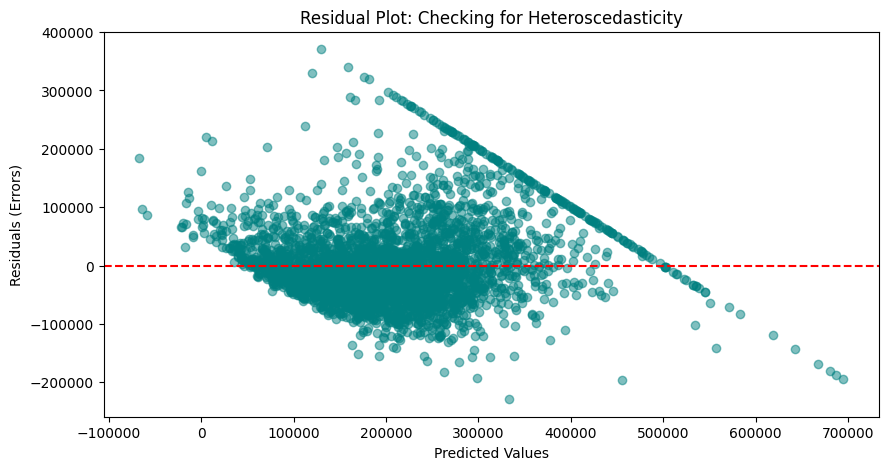

In [8]:
# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Use the plot_residuals function
plot_residuals(y_test, y_pred)

### 3. Prepare for `grid_search_summary` (Requires `k_fold_cross_validation`)

Since `k_fold_cross_validation` is not defined, I will provide a simple mock-up for demonstration purposes. In a real scenario, you would implement a proper k-fold cross-validation.

In [9]:
# Mock K-Fold Cross Validation function for demonstration
def k_fold_cross_validation(model_class, X, y, k=3, **kwargs):
    # This is a placeholder. In a real scenario, this would implement actual CV.
    # For demonstration, we'll return a fixed set of scores.
    print(f"  Running mock K-Fold for {model_class.__name__} with params: {kwargs}")
    # Simulate some scores (e.g., R-squared for regression)
    return [0.75, 0.78, 0.76][:k]

# Demonstrate grid_search_summary with a simple model class
# (Using LinearRegression as a placeholder for model_class)

class MockModel:
    def __init__(self, learning_rate=0.01, max_depth=10):
        self.learning_rate = learning_rate
        self.max_depth = max_depth

    def fit(self, X, y):
        pass # Mock fit

    def predict(self, X):
        return np.random.rand(len(X)) # Mock predict

    def score(self, X, y):
        return np.random.rand() # Mock score

param_grid = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [5, 10]
}

print("\nDemonstrating grid_search_summary:")
best_params = grid_search_summary(MockModel, X, y, param_grid, k=2)
print(f"\nBest parameters found: {best_params}")


Demonstrating grid_search_summary:
  Running mock K-Fold for MockModel with params: {'learning_rate': 0.01, 'max_depth': 5}
Tested: LR=0.01, Depth=5 | Mean CV Acc: 0.7650
  Running mock K-Fold for MockModel with params: {'learning_rate': 0.01, 'max_depth': 10}
Tested: LR=0.01, Depth=10 | Mean CV Acc: 0.7650
  Running mock K-Fold for MockModel with params: {'learning_rate': 0.1, 'max_depth': 5}
Tested: LR=0.1, Depth=5 | Mean CV Acc: 0.7650
  Running mock K-Fold for MockModel with params: {'learning_rate': 0.1, 'max_depth': 10}
Tested: LR=0.1, Depth=10 | Mean CV Acc: 0.7650

Best parameters found: {'lr': 0.01, 'depth': 5, 'score': np.float64(0.765)}


### 4. Prepare Data for Classification and Plot Precision-Recall vs Threshold

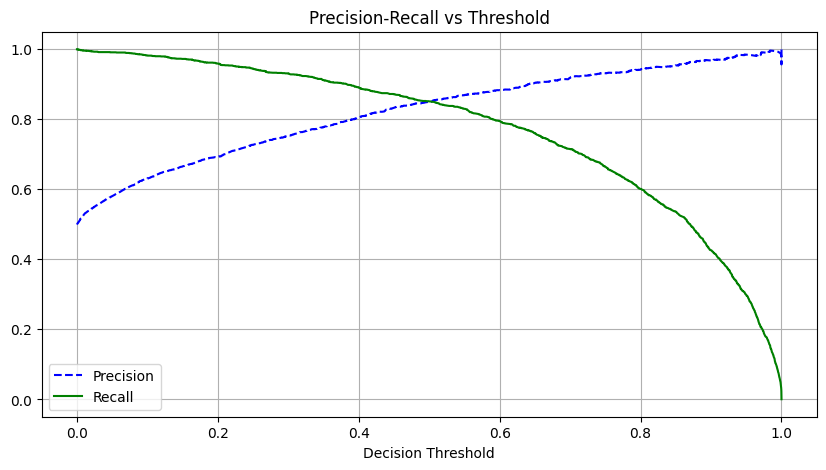

In [10]:
from sklearn.linear_model import LogisticRegression

# For plot_precision_recall_vs_threshold, we need a binary classification problem.
# Let's create one by binarizing the 'median_house_value' target.
# For example, classify houses as 'expensive' (1) if value > median, else 'not expensive' (0).
median_value = df['median_house_value'].median()
df['is_expensive'] = (df['median_house_value'] > median_value).astype(int)

X_clf = df.drop(['median_house_value', 'is_expensive'], axis=1)
y_clf = df['is_expensive']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Train a Logistic Regression model for classification
clf_model = LogisticRegression(max_iter=1000) # Increase max_iter for convergence
clf_model.fit(X_train_clf, y_train_clf)

# Get probability predictions for the positive class (class 1)
probas_pred_clf = clf_model.predict_proba(X_test_clf)[:, 1]

# Use the plot_precision_recall_vs_threshold function
plot_precision_recall_vs_threshold(y_test_clf, probas_pred_clf)